Import the libraries

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

Read the training data

In [190]:
sp_titanic = pd.read_csv('train.csv')

In [4]:
sp_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
sp_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
sp_titanic.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


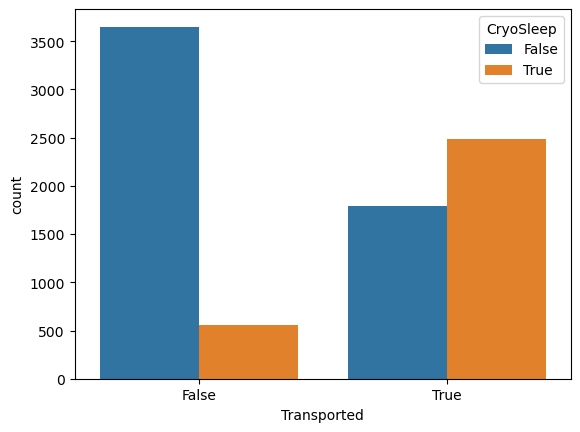

In [7]:
sns.countplot(sp_titanic, x = 'Transported', hue = 'CryoSleep')
plt.show()

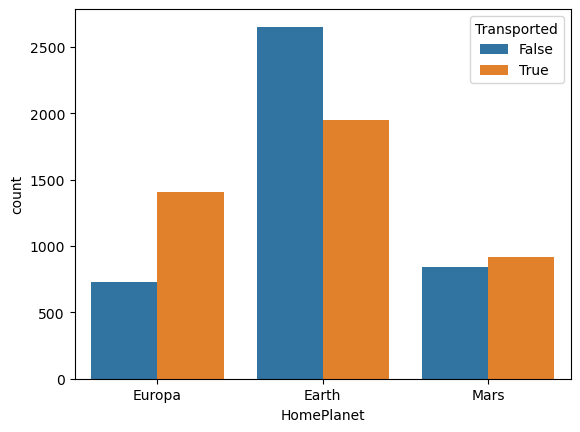

In [13]:
sns.countplot(sp_titanic, x = 'HomePlanet', hue = 'Transported')
plt.show()

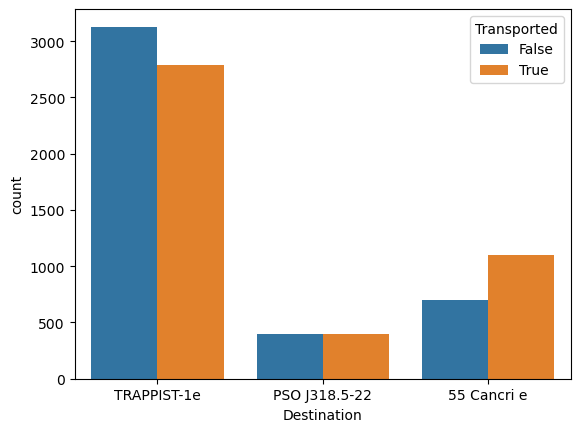

In [15]:
sns.countplot(sp_titanic, x = 'Destination', hue = 'Transported')
plt.show()

In [191]:
def extractDeckNumSide(cabin):
    cabin_split = [None, None, None]
    if(type(cabin) == str):
      cabin_split = cabin.split('/')
    return cabin_split
sp_titanic[['Deck', 'Num', 'Side']] = pd.DataFrame(sp_titanic['Cabin'].apply(lambda cabin: extractDeckNumSide(cabin)).tolist())
sp_titanic.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S


In [192]:
def count_missing_val_per_column(dataframe):
    missing_val_per_col_dict = {}
    for col in dataframe.columns:
        missing_val_per_col_dict[col] = len(dataframe[dataframe[col].isnull()])
    return missing_val_per_col_dict
missing_val_per_col = pd.Series(count_missing_val_per_column(sp_titanic))
missing_val_per_col

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
Deck            199
Num             199
Side            199
dtype: int64

In [20]:
#len(sp_titanic)# - len(sp_titanic.dropna())
len(sp_titanic.dropna())

6606

In [194]:
sp_titanic[['CryoSleep_False', 'CryoSleep_True']] = pd.get_dummies(sp_titanic['CryoSleep'])
sp_titanic[(sp_titanic['CryoSleep_False'] == False) & (sp_titanic['CryoSleep_True'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,CryoSleep_False,CryoSleep_True
92,0099_02,Earth,NaN,G/12/P,TRAPPIST-1e,2.0,False,0.0,0.0,0.0,0.0,0.0,Thewis Connelson,True,G,12,P,False,False
98,0105_01,Earth,NaN,F/21/P,TRAPPIST-1e,27.0,False,0.0,0.0,570.0,2.0,131.0,Carry Cleachrand,False,F,21,P,False,False
104,0110_02,Europa,NaN,B/5/P,TRAPPIST-1e,40.0,False,0.0,331.0,0.0,0.0,1687.0,Aldeba Bootious,False,B,5,P,False,False
111,0115_01,Mars,NaN,F/24/P,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,0.0,NaN,Rohs Pead,True,F,24,P,False,False
152,0173_01,Earth,NaN,E/11/S,TRAPPIST-1e,58.0,False,0.0,985.0,0.0,5.0,0.0,Hilip Grifford,True,E,11,S,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8620,9197_01,Europa,NaN,C/308/P,55 Cancri e,44.0,False,0.0,0.0,0.0,0.0,0.0,Bellus Platch,True,C,308,P,False,False
8651,9227_05,Earth,NaN,G/1498/P,TRAPPIST-1e,8.0,False,0.0,0.0,0.0,0.0,0.0,Hard Hinglendez,False,G,1498,P,False,False
8664,9246_01,Earth,NaN,G/1490/S,TRAPPIST-1e,32.0,False,0.0,0.0,0.0,0.0,0.0,NaN,True,G,1490,S,False,False
8675,9259_01,Earth,NaN,F/1893/P,TRAPPIST-1e,44.0,False,1030.0,1015.0,0.0,11.0,NaN,Annah Gilleyons,True,F,1893,P,False,False


In [195]:
sp_titanic = pd.concat([sp_titanic, pd.get_dummies(sp_titanic['HomePlanet']), pd.get_dummies(sp_titanic['Destination'])], axis = 1)
sp_titanic[(sp_titanic['Earth'] == False) & (sp_titanic['Mars'] == False) & (sp_titanic['Europa'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Num,Side,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
59,0064_02,NaN,True,E/3/S,TRAPPIST-1e,33.0,False,0.0,0.0,NaN,...,3,S,False,True,False,False,False,False,False,True
113,0119_01,NaN,False,A/0/P,TRAPPIST-1e,39.0,False,0.0,2344.0,0.0,...,0,P,True,False,False,False,False,False,False,True
186,0210_01,NaN,True,D/6/P,55 Cancri e,24.0,False,0.0,0.0,NaN,...,6,P,False,True,False,False,False,True,False,False
225,0242_01,NaN,False,F/46/S,TRAPPIST-1e,18.0,False,313.0,1.0,691.0,...,46,S,True,False,False,False,False,False,False,True
234,0251_01,NaN,True,C/11/S,55 Cancri e,54.0,False,0.0,0.0,0.0,...,11,S,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8515,9084_01,NaN,False,E/582/P,TRAPPIST-1e,25.0,False,1258.0,0.0,22.0,...,582,P,True,False,False,False,False,False,False,True
8613,9194_01,NaN,False,E/603/S,55 Cancri e,53.0,False,0.0,4017.0,0.0,...,603,S,True,False,False,False,False,True,False,False
8666,9248_01,NaN,False,F/1792/S,55 Cancri e,38.0,NaN,28.0,1208.0,973.0,...,1792,S,True,False,False,False,False,True,False,False
8674,9257_01,NaN,False,F/1892/P,TRAPPIST-1e,13.0,False,39.0,0.0,1085.0,...,1892,P,True,False,False,False,False,False,False,True


In [102]:
sp_titanic[(sp_titanic['55 Cancri e'] == False) & (sp_titanic['PSO J318.5-22'] == False) & (sp_titanic['TRAPPIST-1e'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Num,Side,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
47,0045_02,Mars,True,F/10/P,NaN,19.0,False,0.0,0.0,0.0,...,10,P,False,True,False,False,True,False,False,False
128,0138_02,Earth,False,E/5/P,NaN,34.0,False,0.0,22.0,0.0,...,5,P,True,False,True,False,False,False,False,False
139,0152_01,Earth,False,F/32/P,NaN,41.0,False,0.0,0.0,0.0,...,32,P,True,False,True,False,False,False,False,False
347,0382_01,NaN,False,G/64/P,NaN,23.0,False,348.0,0.0,0.0,...,64,P,True,False,False,False,False,False,False,False
430,0462_01,Earth,True,G/67/S,NaN,50.0,False,0.0,0.0,0.0,...,67,S,False,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8372,8956_02,Earth,True,G/1453/P,NaN,20.0,False,0.0,0.0,0.0,...,1453,P,False,True,True,False,False,False,False,False
8551,9130_01,Mars,True,F/1765/S,NaN,41.0,False,0.0,0.0,0.0,...,1765,S,False,True,False,False,True,False,False,False
8616,9195_02,Mars,True,F/1779/S,NaN,33.0,False,0.0,0.0,0.0,...,1779,S,False,True,False,False,True,False,False,False
8621,9197_02,Europa,False,C/308/P,NaN,41.0,True,0.0,7964.0,0.0,...,308,P,True,False,False,True,False,False,False,False


In [196]:
sp_titanic[['VIP_False', 'VIP_True']] = pd.get_dummies(sp_titanic['VIP'])
sp_titanic[(sp_titanic['VIP_False'] == False) & (sp_titanic['VIP_True'] == False)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,VIP_False,VIP_True
38,0036_01,Earth,False,F/8/S,55 Cancri e,15.0,NaN,0.0,492.0,48.0,...,True,False,True,False,False,True,False,False,False,False
102,0108_03,Earth,False,G/19/S,TRAPPIST-1e,0.0,NaN,0.0,0.0,0.0,...,True,False,True,False,False,False,False,True,False,False
145,0165_01,Mars,True,F/37/P,TRAPPIST-1e,35.0,NaN,0.0,0.0,0.0,...,False,True,False,False,True,False,False,True,False,False
228,0244_02,Mars,True,F/47/S,55 Cancri e,14.0,NaN,0.0,0.0,0.0,...,False,True,False,False,True,True,False,False,False,False
566,0593_01,Mars,False,D/24/P,TRAPPIST-1e,NaN,NaN,43.0,152.0,182.0,...,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8494,9074_01,Earth,True,G/1460/S,TRAPPIST-1e,0.0,NaN,0.0,0.0,NaN,...,False,True,True,False,False,False,False,True,False,False
8512,9081_06,Earth,False,F/1858/P,PSO J318.5-22,16.0,NaN,0.0,0.0,761.0,...,True,False,True,False,False,False,True,False,False,False
8542,9122_01,Earth,True,G/1469/S,55 Cancri e,55.0,NaN,0.0,0.0,0.0,...,False,True,True,False,False,True,False,False,False,False
8630,9205_03,Europa,True,B/300/P,TRAPPIST-1e,52.0,NaN,0.0,0.0,0.0,...,False,True,False,True,False,False,False,True,False,False


In [197]:
def replaceNansWithZeros(num):
    if(num!=num):
        return 0
    else:
        return num
for col in ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']:
    sp_titanic[col] = sp_titanic[col].apply(lambda num : replaceNansWithZeros(num))
pd.Series(count_missing_val_per_column(sp_titanic))

PassengerId          0
HomePlanet         201
CryoSleep          217
Cabin              199
Destination        182
Age                179
VIP                203
RoomService          0
FoodCourt            0
ShoppingMall         0
Spa                  0
VRDeck               0
Name               200
Transported          0
Deck               199
Num                199
Side               199
CryoSleep_False      0
CryoSleep_True       0
Earth                0
Europa               0
Mars                 0
55 Cancri e          0
PSO J318.5-22        0
TRAPPIST-1e          0
VIP_False            0
VIP_True             0
dtype: int64

In [198]:
sp_titanic['Age'] = sp_titanic['Age'].apply(lambda age : 0 if(age != age) else age)
sp_titanic[sp_titanic['Age'].isnull()]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,CryoSleep_False,CryoSleep_True,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,VIP_False,VIP_True


In [199]:
deck_list = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T']
for i in range(len(deck_list)):
    deck_list[i] += '_Deck'
sp_titanic[deck_list] = pd.get_dummies(sp_titanic['Deck'])
sp_titanic[deck_list]

,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck
0,False,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...
8688,True,False,False,False,False,False,False,False
8689,False,False,False,False,False,False,True,False
8690,False,False,False,False,False,False,True,False
8691,False,False,False,False,True,False,False,False


In [200]:
sp_titanic['Num'] = sp_titanic['Num'].apply(lambda num : 0 if(num == None) else num)
sp_titanic[sp_titanic['Num'].isnull()]['Num']

Series([], Name: Num, dtype: object)

In [201]:
sp_titanic[['P_Side', 'S_Side']] = pd.get_dummies(sp_titanic['Side'])
sp_titanic[['P_Side', 'S_Side']]

,P_Side,S_Side
0,True,False
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
8688,True,False
8689,False,True
8690,False,True
8691,False,True


In [202]:
sp_titanic = sp_titanic.drop(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Name', 'VIP','Deck', 'Side', 'PassengerId'], axis = 1)
pd.Series(count_missing_val_per_column(sp_titanic))

Age                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Transported        0
Num                0
CryoSleep_False    0
CryoSleep_True     0
Earth              0
Europa             0
Mars               0
55 Cancri e        0
PSO J318.5-22      0
TRAPPIST-1e        0
VIP_False          0
VIP_True           0
A_Deck             0
B_Deck             0
C_Deck             0
D_Deck             0
E_Deck             0
F_Deck             0
G_Deck             0
T_Deck             0
P_Side             0
S_Side             0
dtype: int64

In [228]:
scaler = MinMaxScaler()

In [229]:
scaler.fit(sp_titanic.drop('Transported', axis = 1))

MinMaxScaler()

In [230]:
sp_titanic_scaled = scaler.transform(sp_titanic.drop('Transported', axis = 1))

In [231]:
pd.DataFrame(sp_titanic_scaled, columns = sp_titanic.drop('Transported', axis = 1).columns).head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Num,CryoSleep_False,CryoSleep_True,Earth,...,A_Deck,B_Deck,C_Deck,D_Deck,E_Deck,F_Deck,G_Deck,T_Deck,P_Side,S_Side
0,0.493671,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.303797,0.007608,0.000302,0.001064,0.024500,0.001823,0.000000,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.734177,0.003001,0.119948,0.000000,0.299670,0.002030,0.000000,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.417722,0.000000,0.043035,0.015793,0.148563,0.007997,0.000000,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.202532,0.021149,0.002348,0.006428,0.025214,0.000083,0.000528,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [232]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(sp_titanic_scaled, sp_titanic['Transported'], test_size = 0.3)

In [209]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

In [266]:
model = Sequential()
model.add(Dense(27, activation = 'relu'))
model.add(Dense(30, activation = 'relu'))
model.add(Dense(30, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy')

In [267]:
model.fit(X_train, y_train, epochs = 150)

Epoch 1/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.5736 
Epoch 2/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5122  
Epoch 3/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4930  
Epoch 4/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4743  
Epoch 5/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4569  
Epoch 6/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4427  
Epoch 7/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4334  
Epoch 8/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4290 
Epoch 9/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4256
Epoch 10/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4148 
Epoch 11/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4153 
Epoch 12/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4088 
Epoch 13/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4081  
Epoch 14/150
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4062  
Epoch 15/150
191/191 ━

In [268]:
predictions = model.predict(X_test)

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step   


In [269]:
predictions_bool = np.array([x >= 0.5 for x in predictions]).reshape(2608,)

In [254]:
from sklearn.metrics import classification_report, confusion_matrix

In [270]:
print(confusion_matrix(np.array(y_test), predictions_bool))

[[1024  226]
 [ 280 1078]]


In [271]:
print(classification_report(np.array(y_test), predictions_bool))

              precision    recall  f1-score   support

       False       0.79      0.82      0.80      1250
        True       0.83      0.79      0.81      1358

    accuracy                           0.81      2608
   macro avg       0.81      0.81      0.81      2608
weighted avg       0.81      0.81      0.81      2608

